### **Suha Khalil**

### Bonus Assignment: Population Health Informatics

In [261]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# we might also need to use this library to check on things related to operating system :
import os

In [262]:
# define our csv files data path 
data_path = '/home/suhak/hospital_data/output/'

In [263]:
#creating dataframes from the CSV files we got after executing the notebook of aggregating data
df_patient = pd.read_csv(data_path + 'Patient.csv')
df_condition = pd.read_csv(data_path + 'Condition.csv')
df_encounter = pd.read_csv(data_path + 'Encounter.csv')
df_observation = pd.read_csv(data_path + 'Observation.csv')
df_cp = pd.read_csv(data_path + 'CarePlan.csv')

In [264]:
#verify dataframes
print("Patient:", df_patient.shape)
print("Condition:", df_condition.shape)
print("Encounter:", df_encounter.shape)
print("Observation:", df_observation.shape)
print("CarePlan:", df_cp.shape)

Patient: (2160, 13)
Condition: (91321, 7)
Encounter: (147385, 11)
Observation: (2011746, 13)
CarePlan: (17993, 16)


In [265]:
df_patient.head()


,Unnamed: 0,hospital_name,hospital_city,id,gender,birthDate,maritalStatus,patient_city,state,postalCode,country,deceased,deceasedDateTime
0,0,MGH,NaN,209c8400-573b-a7a7-7791-657ca87065ba,female,1951-04-04,Never Married,Marquette,MI,49855,US,False,NaN
1,1,MGH,NaN,dd494021-27cc-8260-1ac2-fe6cf8324538,female,1970-01-12,Married,Marquette,MI,49855,US,False,NaN
2,2,MGH,NaN,865ac475-f245-d9a2-02b8-f64676b0d768,female,1983-02-01,Never Married,Marquette,MI,49855,US,False,NaN
3,3,MGH,NaN,0b4a3b96-af62-3519-7220-684a4c7bf367,male,1953-07-23,Never Married,Marquette,MI,49855,US,False,NaN
4,4,MGH,NaN,6ef52a27-c55c-4830-220e-ab4fa64ce0b7,female,1997-02-15,Married,Marquette,MI,49855,US,False,NaN


In [266]:
df_condition.head()

,Unnamed: 0,patientId,code,encounterId,onsetDateTime,resolvedDateTime,codeText
0,0,002c0bea-51f6-6d8d-a2b6-49f0fad7189d,10509002,002c0bea-51f6-6d8d-0032-0a25671a4a5e,2017-05-13 22:50:16+00:00,2017-05-13 22:50:16+00:00,Acute bronchitis (disorder)
1,1,002c0bea-51f6-6d8d-a2b6-49f0fad7189d,314529007,002c0bea-51f6-6d8d-1eee-4737276b56f5,2023-08-08 16:50:16+00:00,2023-08-08 16:50:16+00:00,Medication review due (situation)
2,2,002c0bea-51f6-6d8d-a2b6-49f0fad7189d,160903007,002c0bea-51f6-6d8d-1eee-4737276b56f5,2023-08-08 17:31:16+00:00,2023-08-08 17:31:16+00:00,Full-time employment (finding)
3,3,002c0bea-51f6-6d8d-a2b6-49f0fad7189d,224295006,002c0bea-51f6-6d8d-1eee-4737276b56f5,2023-08-08 17:31:16+00:00,2023-08-08 17:31:16+00:00,Only received primary school education (finding)
4,4,002c0bea-51f6-6d8d-a2b6-49f0fad7189d,73595000,002c0bea-51f6-6d8d-1eee-4737276b56f5,2023-08-08 17:31:16+00:00,2023-08-08 17:31:16+00:00,Stress (finding)


In [267]:
#filter conditions to Covid 
df_condition = pd.read_csv(data_path + 'Condition.csv')
df_condition_covid = df_condition[df_condition['code'].astype(str) == '840539006']

In [268]:
df_condition_covid.head()


,Unnamed: 0,patientId,code,encounterId,onsetDateTime,resolvedDateTime,codeText
613,613,0169f4b4-7aff-c59e-4239-f8c2b74083ea,840539006,0169f4b4-7aff-c59e-33a1-85dfff8840e6,2021-09-05 15:23:36+00:00,2021-09-05 15:23:36+00:00,Disease caused by severe acute respiratory syn...
1395,1395,047d7725-95e7-4a47-490b-2b29dac63c30,840539006,047d7725-95e7-4a47-b129-4f2c0fa291ca,2021-04-18 07:45:23+00:00,2021-04-18 07:45:23+00:00,Disease caused by severe acute respiratory syn...
1562,1562,04c47d74-efa3-d42b-f31b-81706484a234,840539006,04c47d74-efa3-d42b-6ac6-605f9a135227,2021-01-18 15:03:02+00:00,2021-01-18 15:03:02+00:00,Disease caused by severe acute respiratory syn...
1616,1616,04dc3274-a4c5-25de-fdea-9fd447cfd20a,840539006,04dc3274-a4c5-25de-ce72-3a6b7ded9f83,2020-11-21 13:39:00+00:00,2020-11-21 13:39:00+00:00,Disease caused by severe acute respiratory syn...
1865,1865,054f6d24-964b-48ea-ad15-a7a2df566550,840539006,054f6d24-964b-48ea-5f0d-41eeff1849e4,2020-10-17 00:23:43+00:00,2020-10-17 00:23:43+00:00,Disease caused by severe acute respiratory syn...


In [269]:
df_condition_covid.shape

(151, 7)

In [270]:
print(df_condition['code'].astype(str).value_counts().head(20))


code
314529007    18110
73595000      7495
160903007     6846
66383009      6768
160904001     4239
423315002     2651
422650009     2578
741062008     2312
444814009     2244
18718003      1951
706893006     1741
109570002     1549
424393004     1512
73438004      1477
195662009     1254
162864005     1217
10509002      1048
714628002      937
271737000      869
224299000      786
Name: count, dtype: int64


In [271]:
# check How many patients with Covid we have
print((df_condition['code'].astype(str) == '840539006').sum())

151


In [272]:
df_condition_covid.head()


,Unnamed: 0,patientId,code,encounterId,onsetDateTime,resolvedDateTime,codeText
613,613,0169f4b4-7aff-c59e-4239-f8c2b74083ea,840539006,0169f4b4-7aff-c59e-33a1-85dfff8840e6,2021-09-05 15:23:36+00:00,2021-09-05 15:23:36+00:00,Disease caused by severe acute respiratory syn...
1395,1395,047d7725-95e7-4a47-490b-2b29dac63c30,840539006,047d7725-95e7-4a47-b129-4f2c0fa291ca,2021-04-18 07:45:23+00:00,2021-04-18 07:45:23+00:00,Disease caused by severe acute respiratory syn...
1562,1562,04c47d74-efa3-d42b-f31b-81706484a234,840539006,04c47d74-efa3-d42b-6ac6-605f9a135227,2021-01-18 15:03:02+00:00,2021-01-18 15:03:02+00:00,Disease caused by severe acute respiratory syn...
1616,1616,04dc3274-a4c5-25de-fdea-9fd447cfd20a,840539006,04dc3274-a4c5-25de-ce72-3a6b7ded9f83,2020-11-21 13:39:00+00:00,2020-11-21 13:39:00+00:00,Disease caused by severe acute respiratory syn...
1865,1865,054f6d24-964b-48ea-ad15-a7a2df566550,840539006,054f6d24-964b-48ea-5f0d-41eeff1849e4,2020-10-17 00:23:43+00:00,2020-10-17 00:23:43+00:00,Disease caused by severe acute respiratory syn...


In [273]:
df_encounter.head()

,Unnamed: 0,id,status,code,codeText,start,end,patientId,location,serviceProvider,encounterClass
0,0,209c8400-573b-a7a7-de7c-35b4dd6c2010,finished,185347001,Encounter for problem (procedure),1967-12-31T23:50:24-05:00,1968-01-01T01:10:05-05:00,209c8400-573b-a7a7-7791-657ca87065ba,DLP MARQUETTE GENERAL HOSPITAL LLC,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB
1,1,209c8400-573b-a7a7-23e4-13686147ca30,finished,162673000,General examination of patient (procedure),1969-05-29T00:50:24-04:00,1969-05-29T01:38:22-04:00,209c8400-573b-a7a7-7791-657ca87065ba,BAKER COMMUNITY HEALTH CENTER INC,BAKER COMMUNITY HEALTH CENTER INC,AMB
2,2,209c8400-573b-a7a7-7add-d25aa886e071,finished,162673000,General examination of patient (procedure),1976-06-10T00:50:24-04:00,1976-06-10T01:25:43-04:00,209c8400-573b-a7a7-7791-657ca87065ba,BAKER COMMUNITY HEALTH CENTER INC,BAKER COMMUNITY HEALTH CENTER INC,AMB
3,3,209c8400-573b-a7a7-87e7-dac59b014e9c,finished,424619006,Prenatal visit (regime/therapy),1986-01-02T16:50:24-05:00,1986-01-02T17:05:24-05:00,209c8400-573b-a7a7-7791-657ca87065ba,DLP MARQUETTE GENERAL HOSPITAL LLC,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB
4,4,209c8400-573b-a7a7-7c47-434bef6f2279,finished,702927004,Urgent care clinic (environment),1988-04-14T00:50:24-04:00,1988-04-14T01:33:19-04:00,209c8400-573b-a7a7-7791-657ca87065ba,BAYSIDE DOCS URGENT CARE PLC,BAYSIDE DOCS URGENT CARE PLC,AMB


In [274]:

df_observation.head()


,Unnamed: 0,id,patientId,issuedDate,effectiveDateTime,category,encounter,code,codeText,value,units,snomedCode,observationType
0,0,209c8400-573b-a7a7-976f-3c385ab35e86,209c8400-573b-a7a7-7791-657ca87065ba,2016-11-30T23:50:24.817-05:00,2016-11-30T23:50:24-05:00,procedure,209c8400-573b-a7a7-e166-7a2fbdad00ac,19926-5,FEV1/FVC,10.968,%,NaN,numeric
1,1,209c8400-573b-a7a7-8516-3b7781b31876,209c8400-573b-a7a7-7791-657ca87065ba,2016-11-30T23:50:24.817-05:00,2016-11-30T23:50:24-05:00,laboratory,209c8400-573b-a7a7-e166-7a2fbdad00ac,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,5.96,%,NaN,numeric
2,2,209c8400-573b-a7a7-f009-5bd8cf69f590,209c8400-573b-a7a7-7791-657ca87065ba,2016-11-30T23:50:24.817-05:00,2016-11-30T23:50:24-05:00,vital-signs,209c8400-573b-a7a7-e166-7a2fbdad00ac,8302-2,Body Height,163.3,cm,NaN,numeric
3,3,209c8400-573b-a7a7-c491-307b29a8aace,209c8400-573b-a7a7-7791-657ca87065ba,2016-11-30T23:50:24.817-05:00,2016-11-30T23:50:24-05:00,vital-signs,209c8400-573b-a7a7-e166-7a2fbdad00ac,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,4,{score},NaN,numeric
4,4,209c8400-573b-a7a7-8320-e800910c7a69,209c8400-573b-a7a7-7791-657ca87065ba,2016-11-30T23:50:24.817-05:00,2016-11-30T23:50:24-05:00,vital-signs,209c8400-573b-a7a7-e166-7a2fbdad00ac,29463-7,Body Weight,74.2,kg,NaN,numeric


In [275]:
df_cp.head()

,Unnamed: 0,id,status,patientId,start,end,category,code,codeText,intent,encounter,careTeam,activityCode,activityCodeText,activityStatus,activityLocation
0,0,209c8400-573b-a7a7-239f-d0dd43c5fc99,active,209c8400-573b-a7a7-7791-657ca87065ba,1976-06-10T00:50:24-04:00,NaN,assess-plan,735985000,Diabetes self management plan (record artifact),order,209c8400-573b-a7a7-7add-d25aa886e071,50eeb6c4-91d4-af31-b46a-e5becd4eb910,160670007.0,Diabetic diet (finding),in-progress,BAKER COMMUNITY HEALTH CENTER INC
1,1,209c8400-573b-a7a7-239f-d0dd43c5fc99,active,209c8400-573b-a7a7-7791-657ca87065ba,1976-06-10T00:50:24-04:00,NaN,assess-plan,735985000,Diabetes self management plan (record artifact),order,209c8400-573b-a7a7-7add-d25aa886e071,50eeb6c4-91d4-af31-b46a-e5becd4eb910,229065009.0,Exercise therapy (regime/therapy),in-progress,BAKER COMMUNITY HEALTH CENTER INC
2,2,209c8400-573b-a7a7-0052-c30a2312e284,active,209c8400-573b-a7a7-7791-657ca87065ba,1988-04-14T00:50:24-04:00,NaN,assess-plan,736283006,Chronic obstructive pulmonary disease clinical...,order,209c8400-573b-a7a7-7c47-434bef6f2279,8f8c97c1-7779-4360-209c-e6bc935d7364,229065009.0,Exercise therapy (regime/therapy),in-progress,BAYSIDE DOCS URGENT CARE PLC
3,3,209c8400-573b-a7a7-0052-c30a2312e284,active,209c8400-573b-a7a7-7791-657ca87065ba,1988-04-14T00:50:24-04:00,NaN,assess-plan,736283006,Chronic obstructive pulmonary disease clinical...,order,209c8400-573b-a7a7-7c47-434bef6f2279,8f8c97c1-7779-4360-209c-e6bc935d7364,15081005.0,Pulmonary rehabilitation (regime/therapy),in-progress,BAYSIDE DOCS URGENT CARE PLC
4,4,209c8400-573b-a7a7-b1f9-0549988b5ebf,active,209c8400-573b-a7a7-7791-657ca87065ba,1991-08-01T00:50:24-04:00,NaN,assess-plan,736285004,Hyperlipidemia clinical management plan (recor...,order,209c8400-573b-a7a7-498b-205202abc924,4508d365-49c7-1e51-03cf-cca1bb7cc265,183063000.0,Low salt diet education (procedure),in-progress,DLP MARQUETTE GENERAL HOSPITAL LLC


In [276]:
#Now I need to filter over the Patient ID 
covid_patient_ids = df_condition_covid['patientId'].unique()

In [277]:
#then filter other tables around the same, start with df_patient
df_patient_covid= df_patient[df_patient['id'].isin(covid_patient_ids)]

In [278]:
#then df_encounter
df_encounter_covid = df_encounter[df_encounter['patientId'].isin(covid_patient_ids)]

In [279]:
#Then Observation:
df_observation_covid = df_observation[df_observation['patientId'].isin(covid_patient_ids)]

In [280]:
#Then the CP dataframes:
df_cp_covid = df_cp[df_cp['patientId'].isin(covid_patient_ids)]

In [281]:
#let us check the drop in samples number after filtering
print(len(df_patient), len(df_patient_covid))


2160 151


In [282]:
print(len(df_condition), len(df_condition_covid))

91321 151


### It makes sense to get the same number of samples each time we filter !



### Let's now build a clean COVID BASE that has Patients + Conditions


In [283]:
#attach covid condition into the patients dataset.
df_patient_covid = df_patient[df_patient['id'].isin(covid_patient_ids)]

df_patient_condition = df_patient_covid.merge(
    df_condition_covid,
    left_on='id',
    right_on='patientId',
    how='left'
)

 ### Add Encounters

In [284]:
df_encounter_covid = df_encounter[df_encounter['patientId'].isin(covid_patient_ids)]

df_patient_encounter = df_patient_condition.merge(
    df_encounter_covid,
    on='patientId',
    how='left',
    suffixes=('_cond', '_enc')
)

### Let's now add Observations

In [285]:
df_observation_covid = df_observation[df_observation['patientId'].isin(covid_patient_ids)]

df_full = df_patient_encounter.merge(
    df_observation_covid,
    on='patientId',
    how='left',
    suffixes=('', '_obs')
)

In [286]:
print(df_observation_covid['value'].dtype)


str


In [287]:
print(df_observation_covid['value'].head())

6200     6.06
6201    180.4
6202        2
6203     88.6
6204    27.22
Name: value, dtype: str


In [288]:
# Convert string values to numeric 
df_observation_covid['value'] = pd.to_numeric(
    df_observation_covid['value'],
    errors='coerce'
)

In [289]:
# Drop missing values
df_observation_covid = df_observation_covid.dropna(subset=['value'])

In [290]:
# let's now aggregate observations
df_obs_summary = df_observation_covid.groupby(['patientId', 'code']).agg({
    'value': 'mean'
}).reset_index()

In [291]:
df_obs_pivot = df_obs_summary.pivot(
    index='patientId',
    columns='code',
    values='value'
).reset_index()

In [292]:
print(df_obs_pivot.shape)

(151, 181)


In [293]:
print(df_obs_pivot.columns[:20])

Index(['patientId', '10230-1', '10834-0', '13945-1', '14627-4', '14804-9',
       '14959-1', '1742-6', '1751-7', '17861-6', '18262-6', '19123-9',
       '1920-8', '1960-4', '1975-2', '1988-5', '19926-5', '19994-3', '2019-8',
       '2021-4'],
      dtype='str', name='code')


In [294]:
# after checking what each code represents, I decided to focus the interest on the following codes to check for health trends:
selected_codes = [
    '8302-2',
    '29463-7',
    '39156-5',
    '8462-4',
    '8480-6',
    '8867-4',
    '9279-1',
    '2339-0'
]

cols_to_keep = ['patientId'] + selected_codes

df_obs_filtered = df_obs_pivot[cols_to_keep].copy()

df_obs_filtered = df_obs_filtered.rename(columns={
    '8302-2': 'height',
    '29463-7': 'weight',
    '39156-5': 'bmi',
    '8462-4': 'diastolic_bp',
    '8480-6': 'systolic_bp',
    '8867-4': 'heart_rate',
    '9279-1': 'resp_rate',
    '2339-0': 'glucose'
})

#Build Final Dataset

df_final_clean = df_patient_encounter.drop_duplicates(subset=['patientId']).merge(
    df_obs_filtered,
    on='patientId',
    how='left'
)

In [295]:
print(df_final_clean.shape)


(151, 38)


In [296]:
#Remove Junk Columns:
df_final_clean = df_final_clean.loc[:, ~df_final_clean.columns.str.contains('^Unnamed')]

In [297]:

#  drop columns with too many NaNs

df_final_clean = df_final_clean.loc[:, df_final_clean.isna().mean() < 0.8]

In [298]:
df_final_clean.head()

,hospital_name,id_cond,gender,birthDate,maritalStatus,patient_city,state,postalCode,country,deceased,...,serviceProvider,encounterClass,height,weight,bmi,diastolic_bp,systolic_bp,heart_rate,resp_rate,glucose
0,MGH,7870034f-4203-82f4-540b-353506358ee9,male,1942-05-09,Married,Marquette,MI,49855,US,True,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,180.400000,88.600000,27.220000,81.538462,141.626374,89.118857,15.313407,80.295714
1,MGH,d8c4f92a-6701-e12c-ccfc-81f8980e845e,female,2015-06-18,Never Married,Marquette,MI,49855,US,False,...,UPPER GREAT LAKES FAMILY HEALTH CENTER,AMB,105.607143,22.806667,19.048000,81.266667,129.400000,83.886667,14.743467,NaN
2,MGH,e5d29222-84da-f829-24ad-81326f8945b5,male,2019-08-25,Never Married,Marquette,MI,49855,US,False,...,BAKER COMMUNITY HEALTH CENTER INC,AMB,86.886667,13.425000,16.535000,77.937500,120.375000,81.613125,14.928250,NaN
3,MGH,bc6d1aa2-c85a-961a-6fbd-7108b945c037,male,1997-03-23,Married,Marquette,MI,49855,US,False,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,173.460000,68.216667,22.696000,76.666667,142.000000,85.150000,13.813667,NaN
4,MGH,554ad819-6cd5-ffd8-5e39-b8e15485434b,male,1954-10-03,Divorced,Marquette,MI,49855,US,False,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,171.300000,87.937838,29.948611,58.189189,93.378378,84.294595,14.089270,85.068889


In [316]:
print(df_final_clean.columns.tolist())


['patientId', 'hospital_name', 'gender', 'birthDate', 'age', 'maritalStatus', 'patient_city', 'state', 'postalCode', 'country', 'deceased', 'code_cond', 'codeText_cond', 'onsetDateTime', 'resolvedDateTime', 'encounterId', 'status', 'code_enc', 'codeText_enc', 'start', 'end', 'location', 'serviceProvider', 'encounterClass', 'height', 'weight', 'bmi', 'diastolic_bp', 'systolic_bp', 'heart_rate', 'resp_rate', 'glucose']


### Good ! We’ve got a clean, meaningful patient-level dataset:

**demographics**: gender, birthDate, maritalStatus, patient_city, state, country

**COVID condition info**: code_cond, onsetDateTime, resolvedDateTime, codeText_cond

**encounter info**: status, code_enc, codeText_enc, start, end, location, encounterClass

**vitals/labs**: height, weight, bmi, diastolic_bp, systolic_bp, heart_rate, resp_rate, glucose

In [301]:
# I will change the birthdate into age now 
df_final_clean['birthDate'] = pd.to_datetime(df_final_clean['birthDate'])
df_final_clean['age'] = 2026 - df_final_clean['birthDate'].dt.year
df_final_clean.to_csv('covid_final_clean.csv', index=False)

In [302]:
#change column order 
df_final_clean = df_final_clean[
    [
        'patientId',
        'hospital_name',
        'gender',
        'birthDate',
        'age',
        'maritalStatus',
        'patient_city',
        'state',
        'postalCode',
        'country',
        'deceased',
        'code_cond',
        'codeText_cond',
        'onsetDateTime',
        'resolvedDateTime',
        'encounterId',
        'status',
        'code_enc',
        'codeText_enc',
        'start',
        'end',
        'location',
        'serviceProvider',
        'encounterClass',
        'height',
        'weight',
        'bmi',
        'diastolic_bp',
        'systolic_bp',
        'heart_rate',
        'resp_rate',
        'glucose'
    ]
]

In [303]:
df_final_clean.head()

,patientId,hospital_name,gender,birthDate,age,maritalStatus,patient_city,state,postalCode,country,...,serviceProvider,encounterClass,height,weight,bmi,diastolic_bp,systolic_bp,heart_rate,resp_rate,glucose
0,7870034f-4203-82f4-540b-353506358ee9,MGH,male,1942-05-09,84,Married,Marquette,MI,49855,US,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,180.400000,88.600000,27.220000,81.538462,141.626374,89.118857,15.313407,80.295714
1,d8c4f92a-6701-e12c-ccfc-81f8980e845e,MGH,female,2015-06-18,11,Never Married,Marquette,MI,49855,US,...,UPPER GREAT LAKES FAMILY HEALTH CENTER,AMB,105.607143,22.806667,19.048000,81.266667,129.400000,83.886667,14.743467,NaN
2,e5d29222-84da-f829-24ad-81326f8945b5,MGH,male,2019-08-25,7,Never Married,Marquette,MI,49855,US,...,BAKER COMMUNITY HEALTH CENTER INC,AMB,86.886667,13.425000,16.535000,77.937500,120.375000,81.613125,14.928250,NaN
3,bc6d1aa2-c85a-961a-6fbd-7108b945c037,MGH,male,1997-03-23,29,Married,Marquette,MI,49855,US,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,173.460000,68.216667,22.696000,76.666667,142.000000,85.150000,13.813667,NaN
4,554ad819-6cd5-ffd8-5e39-b8e15485434b,MGH,male,1954-10-03,72,Divorced,Marquette,MI,49855,US,...,DLP MARQUETTE GENERAL HOSPITAL LLC,AMB,171.300000,87.937838,29.948611,58.189189,93.378378,84.294595,14.089270,85.068889


## Total Patients Vs Covid Patients 


In [304]:
total_patients = len(df_patient)
covid_patients = len(df_final_clean)

percent_covid = covid_patients / total_patients * 100

print("Total patients:", total_patients)
print("COVID patients:", covid_patients)
print("Percent COVID:", percent_covid)

Total patients: 2160
COVID patients: 151
Percent COVID: 6.9907407407407405


**Insight:**  
The percentage of COVID-19 patients is approximately 7%, which represents a moderate but relatively low proportion of the overall patient population. This indicates that COVID cases, while present, do not dominate the dataset and most patients are associated with other medical conditions.

## Demographics:

In [305]:
# Gender Distribution :
df_final_clean['gender'].value_counts()

gender
female    77
male      74
Name: count, dtype: int64

**Insight:**  
The gender distribution shows that (male/female) patients numbers are very close.  
This suggests that COVID infections in this dataset are balanced across genders.

In [306]:
#Age Statistics :
df_final_clean['age'].describe()

count    151.000000
mean      44.708609
std       22.759493
min        5.000000
25%       22.500000
50%       49.000000
75%       62.000000
max       87.000000
Name: age, dtype: float64

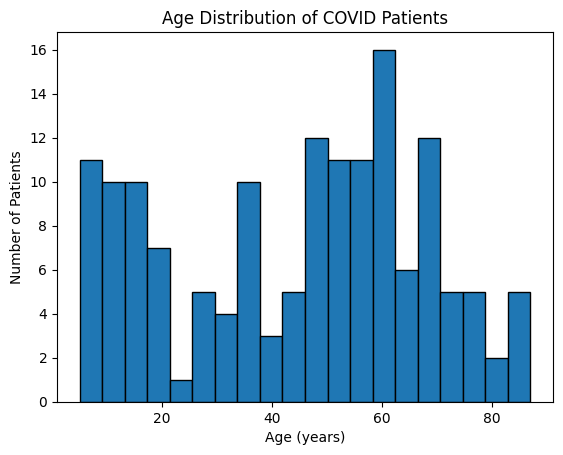

In [317]:
#Plot age 
age_plot = df_final_clean['age'].hist(bins=20, edgecolor='black')

age_plot.set_title('Age Distribution of COVID Patients')
age_plot.set_xlabel('Age (years)')
age_plot.set_ylabel('Number of Patients')

plt.grid(False)


 
**Insight:**  
The age distribution shows that COVID patients span a wide range of ages, from young children to elderly individuals.  
The median age is approximately 49 years, indicating that most patients fall within the middle-aged group.  
While older patients are present, the distribution suggests that COVID affects a broad age spectrum rather than being concentrated in a narrow older age range. The age group with the heighest number of COVID infected people was 60 years old.

In [308]:
#Marital Status :
df_final_clean['maritalStatus'].value_counts()

maritalStatus
Never Married    66
Married          55
Divorced         21
Widowed           9
Name: count, dtype: int64

**Insight:**
The distribution shows a fair distribution between Never Married and Married cases, which reminds us that this factor does not really play any role clinically.

## Mortality insights


In [309]:
df_final_clean['deceased'].value_counts()

deceased
False    141
True      10
Name: count, dtype: int64

In [310]:
df_final_clean['deceased'] = df_final_clean['deceased'].astype(bool)
mortality_rate = df_final_clean['deceased'].mean() * 100
print("Mortality rate (%):", mortality_rate)

Mortality rate (%): 6.622516556291391


**Insight:**  
The mortality rate among COVID patients is approximately 6.6%.  
This suggests that the majority of patients survived, although mortality is still a significant outcome to monitor.

## Clinical Measurements and Health Indicators

In [311]:
df_final_clean[
    ['bmi','systolic_bp','diastolic_bp','heart_rate','resp_rate','glucose']
].describe()

,bmi,systolic_bp,diastolic_bp,heart_rate,resp_rate,glucose
count,151.000000,151.000000,151.000000,151.000000,151.000000,69.000000
mean,26.038106,119.109347,79.230276,88.488586,16.045861,83.430843
std,5.620591,14.377292,9.947970,10.802403,2.489985,7.808791
min,14.695000,81.909091,50.090909,72.923545,13.104071,69.750000
25%,22.352778,107.741176,73.272727,81.374586,14.508156,79.759231
50%,27.860000,120.375000,79.250000,85.385333,15.124900,82.135000
75%,29.327429,129.552632,85.041667,91.843833,16.121811,84.065000
max,47.770000,157.702381,108.794521,129.898000,24.192000,113.355455


**Insight:**  
The summary statistics show that:
- Average BMI is around 26, indicating overweight population.
- Blood pressure values suggest normal cardiovascular conditions.
- Heart rate and respiratory rate fall within expected physiological ranges.

These metrics help characterize the general health status of COVID patients.

## Encounter Analysis

In [312]:
df_final_clean['encounterClass'].value_counts()

encounterClass
AMB     137
EMER     12
IMP       2
Name: count, dtype: int64

**Insight:**  
Most encounters are classified as AMB (Ambulatory Care), indicating that the majority of COVID cases were managed in outpatient settings.

## Surveillance Over time

/tmp/ipykernel_4393/564793862.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_final_clean['onsetDateTime'].dt.to_period('M')


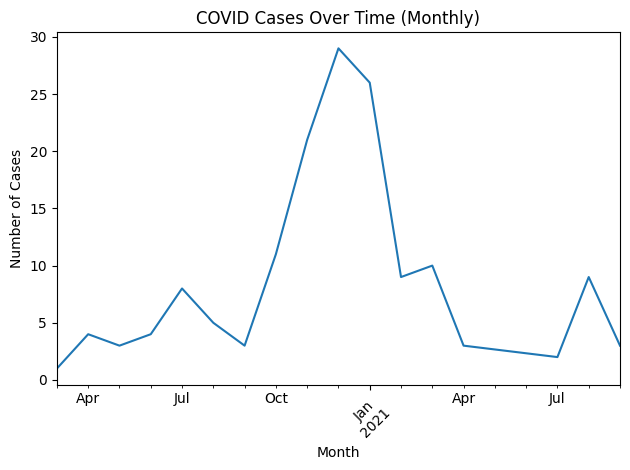

In [ ]:

# Convert onsetDateTime to datetime for time-series analysis
df_final_clean['onsetDateTime'] = pd.to_datetime(
    df_final_clean['onsetDateTime'],
    errors='coerce'
)

cases_over_time = df_final_clean.groupby(
    df_final_clean['onsetDateTime'].dt.to_period('M')
).size()

ax = cases_over_time.plot()

ax.set_title("COVID Cases Over Time (Monthly)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**  
The time-series plot shows fluctuations in COVID case counts over time.  
Peaks in the curve around December 2020 indicate an outbreaks, while declines suggest periods of reduced transmission.

## Geographic Distribution

In [314]:
df_final_clean['patient_city'].value_counts()

patient_city
Marquette    126
Baraga        18
Houghton       6
Calumet        1
Name: count, dtype: int64

**Insight:**  
Most patients are concentrated in (Marquette, MI), which is expected given the dataset’s geographic scope. we originally generated a higher number of synthetic patients from Marquette which led to this cases distribution.

## Conclusion>>> The Main Insights I got from this analytical project:

This analysis explored COVID-19 patient data by integrating multiple healthcare datasets.  
Key findings include:

- COVID patients represent approximately 7% of the total population  
- The majority of cases are outpatient encounters which indicates that the symptoms were manageable at home for most cases. 
- Patients are predominantly within the age of 22-62, with a median of 49 Years.  
- Mortality rate remains relatively low considering 6.6%.
- Clinical measurements indicate good general health conditions for most patients.

Overall, this dataset provides valuable insights into COVID-19 trends, patient demographics, and healthcare utilization.

In [315]:
# Export the final data to a CSV file to implement it in Google Looker Studio:
df_final_clean.to_csv("covid_dashboard.csv", index=False)